# 1.2 Elimination, Pivoting, and A = LU

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Chapter I — Matrices, Elimination, and Subspaces",
    number="1.2",
    title="Elimination, Pivoting, and A = LU",
    blurb="Write Gaussian elimination out, keep a record of what it did, and "
    "the record is a factorization. Then find the matrix where forgetting to "
    "pivot destroys every digit of the answer.",
    difficulty="intermediate",
    estimate="90–120 min",
)

<ECP header: 2532 chars of HTML>

## Notebook overview

Everybody learns to solve $A\mathbf{x} = \mathbf{b}$ by elimination: subtract
multiples of one row from the others until the system is triangular, then work
backwards. The idea is two thousand years old and it is still, essentially
unchanged, what your computer does.

What is worth an hour is the bookkeeping. If you write down *which* multiples
you subtracted, those numbers assemble into a lower triangular matrix $L$, the
triangular system you were left with is $U$, and together they satisfy
$A = LU$. Elimination and factorization are not two topics. The factorization
is simply elimination that kept a receipt, and the receipt is what lets you
solve fifty different right-hand sides for the price of one elimination plus
fifty cheap triangular sweeps. We measure that: it comes out about thirty times
faster.

The other half of the notebook is about a decision the textbook version glosses
over. At each step you divide by the **pivot**, the diagonal entry, and nothing
guarantees it is not tiny. We build the matrix where the natural pivot is
$10^{-18}$, watch the unpivoted algorithm return $\mathbf{x} = (0, 1)$ where
the true answer is $(1, 1)$ — not inaccurate, *entirely wrong* — and then watch
**partial pivoting**, which is nothing more than "swap in the largest available
entry first", return the exact answer. It costs a comparison per step and it is
the difference between a working algorithm and a broken one.

Two things here are measured rather than asserted, and both come out slightly
against the textbook. The operation count of elimination is exactly
$n(n-1)(4n+1)/6$, which approaches $\tfrac23 n^3$ but is $0.4\%$ below it even
at $n = 200$; and the *measured* running time of LAPACK's factorization scales
closer to $n^{2.5}$ than $n^3$ at any size you can comfortably run, for reasons
that are about memory rather than arithmetic and that
[§1.1](four-ways-to-multiply.ipynb) already explained.

> **How to read a check.** A `validate` line prints ✓ or ✗ by comparing a
> result against something the computation did not assume — here, mostly the
> reconstruction $PA = LU$, which the factorization routine was never asked to
> satisfy. A ✗ flags a mismatch to investigate, never a verdict on its own.

> **Scope.** The definitive treatment of pivoting and growth is Higham
> {cite}`higham2002`, Chapters 9 and 22; Trefethen and Bau
> {cite}`trefethen1997`, Lectures 20–22, give the shorter version with the
> stability argument this notebook follows.

## Theory in brief

### Elimination as a sequence of row operations

Given $A \in \mathbb{R}^{n\times n}$, step $k$ of elimination uses row $k$ to
clear the entries below the diagonal in column $k$. For each row $i > k$ it
forms the **multiplier**

```{math}
:label: eq-lu-multiplier
\ell_{ik} = \frac{a_{ik}}{a_{kk}}
```

and replaces row $i$ by row $i$ minus $\ell_{ik}$ times row $k$. The divisor
$a_{kk}$ is the **pivot**. After $n-1$ such steps the matrix is upper
triangular; call it $U$.

Each row operation is itself a matrix multiplication. Clearing column $k$ is
left-multiplication by an elementary matrix $E_k$ that is the identity with the
multipliers of {eq}`eq-lu-multiplier` placed in column $k$ below the diagonal,
negated. So $E_{n-1}\cdots E_1 A = U$, and therefore
$A = E_1^{-1}\cdots E_{n-1}^{-1} U$. The pleasant surprise is that the inverse
of such an $E_k$ is the same matrix with the signs flipped, and that the
product of all of them is just the collection of multipliers assembled in
place. Writing $L$ for that product,

```{math}
:label: eq-lu-factorization
A = LU,
```

with $L$ **unit lower triangular** (ones on the diagonal, the multipliers
$\ell_{ik}$ below it) and $U$ upper triangular. No work beyond the elimination
itself is needed to obtain $L$: you simply store each multiplier where the zero
it created would have gone.

### Why the factorization is worth having

Once $A = LU$, solving $A\mathbf{x} = \mathbf{b}$ splits into two triangular
solves,

```{math}
:label: eq-lu-two-solves
L\mathbf{y} = \mathbf{b} \quad\text{(forward)}, \qquad
U\mathbf{x} = \mathbf{y} \quad\text{(backward)},
```

each costing $n^2$ operations against the $\sim\tfrac23 n^3$ of the
factorization. For one right-hand side that is no saving. For many — which is
the normal situation, in least squares, in time-stepping, in Newton iterations
— it is a factor of $O(n)$, and it is the entire reason numerical software is
organised around factorizations rather than around solvers.

### Pivoting

{eq}`eq-lu-multiplier` divides by $a_{kk}$, and two things can go wrong. If the
pivot is exactly zero the algorithm stops. If it is merely *small*, the
multipliers are large, the elimination adds large multiples of one row to
another, and the original entries are swamped: information is destroyed by
cancellation, exactly as in
[§0.2](../00-machine/floating-point.ipynb).

**Partial pivoting** fixes both. Before clearing column $k$, find the largest
entry in that column at or below the diagonal and swap its row into position
$k$. Every multiplier then satisfies $|\ell_{ik}| \le 1$ by construction. The
row swaps are recorded in a permutation matrix $P$, and the factorization
becomes

```{math}
:label: eq-lu-pivoted
PA = LU .
```

This is what `scipy.linalg.lu_factor` computes and what every general-purpose
dense solver in existence uses.

### Growth, and the honest caveat

Bounded multipliers do not by themselves bound the *entries of $U$*. The
relevant quantity is the **growth factor**

```{math}
:label: eq-lu-growth
\rho = \frac{\max_{i,j,k} |a_{ij}^{(k)}|}{\max_{i,j}|a_{ij}|},
```

the largest entry appearing anywhere during the elimination, relative to the
largest entry of $A$. The backward error of the computed solution is
proportional to $\rho$, so a large $\rho$ means the answer, though it solves a
nearby problem, may solve one that is not near enough.

In practice $\rho$ is almost always modest — of order $n^{1/2}$ or so on random
matrices. But partial pivoting does not *guarantee* it: Wilkinson's matrix,
built in Exercise 7, attains $\rho = 2^{n-1}$ exactly, which at $n = 60$
exceeds $10^{17}$ and destroys every digit. That the worst case is
catastrophic while the average case is benign, with no satisfying explanation
of why practice is so much kinder than theory, is one of the genuine open
embarrassments of the subject {cite}`higham2002`.

---
## Setup

Data and instruments only: the worked matrices and the timing meter of
[§0.1](../00-machine/arrays-and-vectorization.ipynb).
The elimination step and the LU factorizer are built in Exercises 1-3,
where they are the lesson.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import time

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu, lu_factor, lu_solve, solve

from ecp import validate
from ecp import linalg as la
from ecp.style import use_style

use_style()
rng = np.random.default_rng(0)  # every random matrix below comes from this seed

EPS = np.finfo(float).eps
np.set_printoptions(precision=5, suppress=True, linewidth=100)


# instrument: the timing meter of §0.1 — plumbing for every race in the
# course, not any exercise's lesson.
def bench(fn, repeats=3):
    """Median wall-clock time of a zero-argument call, in seconds.

    The same helper as sections 0.1 and 1.1. Timings are reported as ratios or
    fitted exponents, never as absolute seconds, because absolutes do not
    transfer between machines.

    Parameters
    ----------
    fn : callable
        Zero-argument callable to time; called once first to warm any cache.
    repeats : int, default 3
        Number of timed repetitions.

    Returns
    -------
    float
        Median elapsed time in seconds.
    """
    fn()
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn()
        times.append(time.perf_counter() - t0)
    return float(np.median(times))


# The worked 3x3 of Exercises 1-2, chosen so that every multiplier and every
# entry of U is a small integer and the whole elimination can be checked by eye.
A3 = np.array(
    [
        [2.0, 1.0, -1.0],
        [4.0, 5.0, -3.0],
        [-2.0, 5.0, -2.0],
    ]
)
b3 = np.array([3.0, 11.0, 6.0])  # chosen so the exact solution is (1, 2, 1)

## Exercise 1: Elimination, one step at a time

We begin by doing it by hand, on a matrix small enough that every number is an
integer and any slip is visible.

```{math}
:label: eq-lu-example
A = \begin{bmatrix} 2 & 1 & -1\\ 4 & 5 & -3\\ -2 & 5 & -2 \end{bmatrix},
\qquad
\mathbf{b} = \begin{pmatrix} 3\\ 11\\ 6 \end{pmatrix},
```

whose exact solution is $\mathbf{x} = (1, 2, 1)^{\top}$, since
$\mathbf{b} = A\mathbf{x}$ by construction.

Step 1 uses the pivot $a_{11} = 2$. The multipliers from
{eq}`eq-lu-multiplier` are $\ell_{21} = 4/2 = 2$ and
$\ell_{31} = -2/2 = -1$; subtracting $\ell_{21}$ times row 1 from row 2 and
$\ell_{31}$ times row 1 from row 3 clears the first column. Step 2 uses the new
pivot $a_{22} = 3$ and the single multiplier $\ell_{32} = 6/3 = 2$. What is
left is upper triangular:

$$
U = \begin{bmatrix} 2 & 1 & -1\\ 0 & 3 & -1\\ 0 & 0 & -1 \end{bmatrix}.
$$

Every multiplier and every entry of $U$ is an integer, so the whole
computation is exact in `float64` and can be checked without any tolerance at
all. That is unusual and deliberate: it lets Exercise 2 make an *exact* claim
about the factorization before Exercise 3 introduces anything approximate.

**Part a)** Apply the two elimination steps to $A$ of {eq}`eq-lu-example` with
explicit array slicing (`M[i, k:] -= mult * M[k, k:]`), printing the working
matrix after each step, and confirm the result equals the $U$ above exactly.

**Part b)** Apply the identical operations to $\mathbf{b}$ and confirm the
reduced right-hand side is $(3, 5, -1)^{\top}$.

**Part c)** Draw the two tableaux with
`ecp.linalg.elimination_tableau(ax, M, b, pivot=..., eliminated=...)`,
highlighting the active pivot and the entries just driven to zero.

In [3]:
# (solution hidden on the public site)


after step 1  (pivot 2, multipliers ['2', '-1']):
[[ 2.  1. -1.  3.]
 [ 0.  3. -1.  5.]
 [ 0.  6. -3.  9.]] 

after step 2  (pivot 3, multipliers ['2']):
[[ 2.  1. -1.  3.]
 [ 0.  3. -1.  5.]
 [ 0.  0. -1. -1.]] 

U matches the stated matrix exactly: True
reduced right-hand side: [ 3.  5. -1.]  (exactly (3, 5, -1): True)


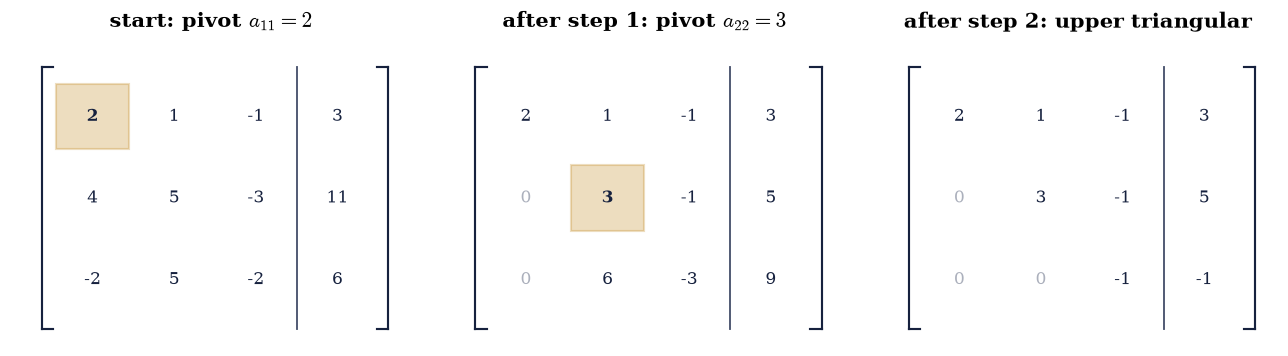

In [4]:
# (solution hidden on the public site)


### Validation 1

Every check here is exact, with `rtol=0` and `atol=0`. The entries of
{eq}`eq-lu-example` were chosen so that no rounding occurs anywhere in the
elimination, so any deviation would be a genuine error in the arithmetic rather
than a floating-point artefact.

In [5]:
validate.close(M, U_expected, "elimination produces the stated U exactly",
               rtol=0.0, atol=0.0)
validate.close(c, np.array([3.0, 5.0, -1.0]),
               "and reduces b to (3, 5, -1) exactly", rtol=0.0, atol=0.0)
validate.close(
    np.array([multipliers[(1, 0)], multipliers[(2, 0)], multipliers[(2, 1)]]),
    np.array([2.0, -1.0, 2.0]),
    "the three multipliers of Eq. 1 are 2, -1, 2", rtol=0.0, atol=0.0,
)
validate.close(M, np.triu(M), "U is upper triangular: nothing below the diagonal",
               rtol=0.0, atol=0.0)

✓  elimination produces the stated U exactly   [max|Δ| = 0 (rtol=0, atol=0)]
✓  and reduces b to (3, 5, -1) exactly   [max|Δ| = 0 (rtol=0, atol=0)]
✓  the three multipliers of Eq. 1 are 2, -1, 2   [max|Δ| = 0 (rtol=0, atol=0)]
✓  U is upper triangular: nothing below the diagonal   [max|Δ| = 0 (rtol=0, atol=0)]


True

## Exercise 2: The multipliers are $L$

Here is the observation that turns an algorithm into a factorization. The three
multipliers of Exercise 1 were $\ell_{21} = 2$, $\ell_{31} = -1$,
$\ell_{32} = 2$. Place them below the diagonal of an identity matrix, in the
positions of the zeros they created:

$$
L = \begin{bmatrix} 1 & 0 & 0\\ 2 & 1 & 0\\ -1 & 2 & 1 \end{bmatrix}.
$$

Then $LU = A$ exactly, which is {eq}`eq-lu-factorization`. Nothing was computed
to obtain $L$ beyond the elimination itself; the multipliers were already
there, and storing them costs nothing because the space they occupy is exactly
the space the zeros would have occupied. Production implementations store $L$
and $U$ in a single array for that reason, and `scipy.linalg.lu_factor` returns
precisely such a packed array.

The reason it works is worth a sentence. Each elimination step is
left-multiplication by an elementary matrix, and the inverse of such a matrix
is obtained by flipping the signs of its multipliers. Undoing the steps in
reverse order therefore assembles the multipliers with their original signs,
with no interference between columns — which is a small miracle that fails as
soon as row swaps are introduced, and is why Exercise 3 has to be careful.

**Part a)** Write `lu_no_pivot(A)` returning $(L, U)$: run the elimination of
Exercise 1 for general $n$, storing each multiplier from
{eq}`eq-lu-multiplier` into `L[i, k]` as it is formed.

**Write this one yourself** — the implementation is the lesson.

**Part b)** Run it on $A$ of {eq}`eq-lu-example` and confirm $L$ equals the
matrix above exactly, that $L$ is unit lower triangular under `np.tril` and
`np.diag`, and that $LU = A$ exactly.

**Part c)** Confirm it agrees with the library on a case where no pivoting is
needed: for the symmetric positive definite `la.random_spd(6, rng)` — which
never requires a row swap — check that `lu_no_pivot` reproduces
`scipy.linalg.lu` to $10^{-12}$, and that $\det A = \prod_i u_{ii}$.

In [6]:
# (solution hidden on the public site)


L =
 [[ 1.  0.  0.]
 [ 2.  1.  0.]
 [-1.  2.  1.]]
U =
 [[ 2.  1. -1.]
 [ 0.  3. -1.]
 [ 0.  0. -1.]]

L matches exactly          : True
L is unit lower triangular : True
L @ U == A exactly         : True
det A = prod(diag U)       : -6.0 (np.linalg.det gives -6.0)

on a 6x6 SPD matrix (no swaps needed):
  our L vs scipy's : 2.776e-17
  our U vs scipy's : 2.220e-16
  scipy needed no row swaps: True


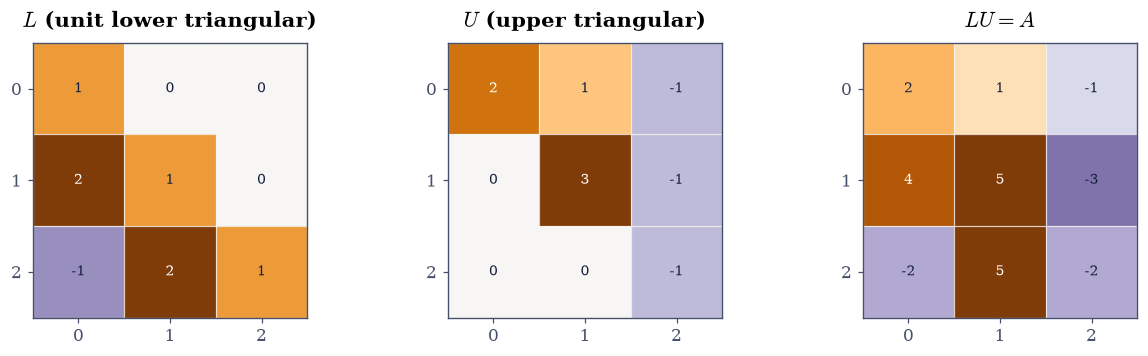

In [7]:
# (solution hidden on the public site)


### Validation 2

The reconstruction $LU = A$ is the check that matters, and it is independent:
the factorization routine was asked to eliminate, not to reproduce $A$. On
{eq}`eq-lu-example` it holds exactly; on the SPD matrix it is compared against
an independent implementation, and the determinant identity provides a third,
unrelated confirmation.

In [8]:
validate.close(L3, L_expected, "L holds the multipliers, exactly as stated",
               rtol=0.0, atol=0.0)
validate.close(np.diag(L3), np.ones(3), "L has a unit diagonal", rtol=0.0, atol=0.0)
validate.close(L3, np.tril(L3), "L is lower triangular", rtol=0.0, atol=0.0)
validate.close(L3 @ U3, A3, "L @ U reproduces A exactly (Eq. 2)",
               rtol=0.0, atol=0.0)
validate.close(np.prod(np.diag(U3)), np.linalg.det(A3),
               "det A = product of the pivots = -6", rtol=0.0, atol=1e-12)
validate.close(Ls @ Us, S6,
               "and on a 6x6 SPD matrix the reconstruction holds to 1e-12",
               rtol=0.0, atol=1e-12)
validate.close(Ls, L_lib, "our L agrees with scipy.linalg.lu", rtol=0.0, atol=1e-12)

✓  L holds the multipliers, exactly as stated   [max|Δ| = 0 (rtol=0, atol=0)]
✓  L has a unit diagonal   [max|Δ| = 0 (rtol=0, atol=0)]
✓  L is lower triangular   [max|Δ| = 0 (rtol=0, atol=0)]
✓  L @ U reproduces A exactly (Eq. 2)   [max|Δ| = 0 (rtol=0, atol=0)]
✓  det A = product of the pivots = -6   [got -6 vs expected -6 (rtol=0, atol=1e-12)]
✓  and on a 6x6 SPD matrix the reconstruction holds to 1e-12   [max|Δ| = 2.22045e-16 (rtol=0, atol=1e-12)]
✓  our L agrees with scipy.linalg.lu   [max|Δ| = 2.77556e-17 (rtol=0, atol=1e-12)]


True

## Exercise 3: The matrix that breaks it, and the one-line repair

Everything so far assumed the pivot was a reasonable number. This exercise
builds the case where it is not, and it is worth doing carefully because the
failure is not a loss of a few digits. It is total.

Consider the $2\times2$ system

```{math}
:label: eq-lu-tiny-pivot
\begin{bmatrix} \delta & 1\\ 1 & 1 \end{bmatrix}
\begin{pmatrix} x_1\\ x_2 \end{pmatrix}
= \begin{pmatrix} 1 + \delta\\ 2 \end{pmatrix},
\qquad \delta = 10^{-18},
```

whose exact solution is $\mathbf{x} = (1, 1)^{\top}$ for every $\delta$, as
substitution confirms. The matrix is perfectly well conditioned:
$\kappa \approx 2.6$, so [§0.2](../00-machine/floating-point.ipynb) entitles us
to essentially all sixteen digits.

Eliminate without pivoting. The multiplier is $\ell_{21} = 1/\delta = 10^{18}$,
and the second row becomes $(0,\ 1 - 10^{18})$ with right-hand side
$2 - 10^{18}(1+\delta)$. Both of those are, in `float64`, indistinguishable
from $-10^{18}$, because adding 1 to $10^{18}$ changes nothing: the spacing
there is 128. So $x_2$ comes out as $1$ — correct, by luck — and then back
substitution computes
$x_1 = (1 + \delta - x_2)/\delta = (1 + \delta - 1)/\delta$, in which the
numerator suffers complete cancellation and returns $0$. The computed answer is
$(0, 1)^{\top}$: the first component has no correct digits, and not because the
problem was hard.

Partial pivoting swaps the rows before eliminating. The multiplier becomes
$\delta$ rather than $1/\delta$, nothing is swamped, and the computed answer is
exactly $(1, 1)^{\top}$. The cost is one comparison per column.

**Part a)** Write `lu_pivot(A)` returning $(p, L, U, \rho)$: the same
elimination, but at each step select the row with the largest $|a_{ik}|$ for
$i \ge k$, swap it into place, record the permutation as an index array `p`,
swap the already-computed part of $L$ along with it, and track the growth
factor {eq}`eq-lu-growth`.

**Write this one yourself** — the implementation is the lesson.

**Part b)** Solve {eq}`eq-lu-tiny-pivot` at $\delta = 10^{-18}$ both ways,
using the forward and back substitutions defined at the top of this
solution (Exercise 4 puts them through their paces), and report the computed $\mathbf{x}$ and the error against
$(1,1)^{\top}$. Confirm $\kappa(A) < 3$, so the problem is not to blame.

**Part c)** Sweep $\delta$ from $10^{-1}$ down to $10^{-20}$ and plot the
relative error of both routes. Confirm that every multiplier produced by
`lu_pivot` satisfies $|\ell_{ik}| \le 1$, over 200 random matrices of random
sizes.

In [9]:
# (solution hidden on the public site)


delta = 1e-18,  exact solution (1, 1),  kappa(A) = 2.618
  without pivoting : x = [0. 1.]   max error 1.000e+00
  with pivoting    : x = [1. 1.]   max error 0.000e+00

  multiplier without pivoting : 1.000e+18
  multiplier with pivoting    : 1.000e-18

200 random matrices: largest multiplier 0.999163, worst relative |PA - LU| 3.54e-16


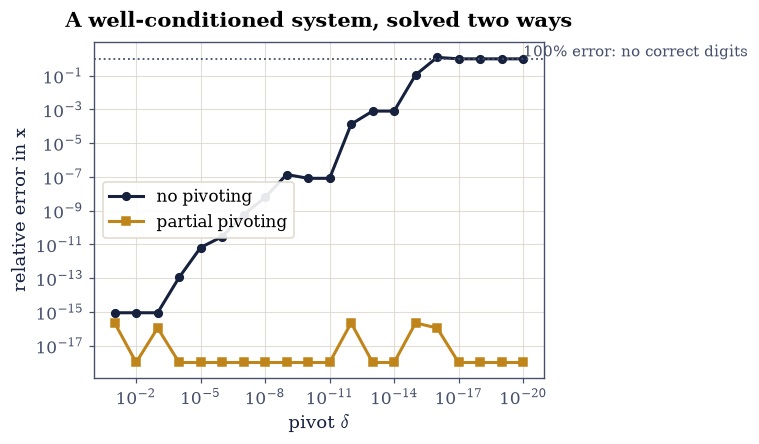

In [10]:
# (solution hidden on the public site)


### Validation 3

The pivoted answer is checked to be exactly $(1,1)$, and the unpivoted one to
have *no* correct digits — both are exact statements about what correctly
rounded arithmetic produces here, not estimates. The conditioning check is what
makes the comparison fair: it rules out the possibility that the problem, not
the algorithm, was at fault.

In [11]:
validate.close(x_pv, np.ones(2),
               "with pivoting the answer is exactly (1, 1)", rtol=0.0, atol=0.0)
validate.check(
    np.abs(x_no - 1).max() >= 1.0,
    "without pivoting the relative error is 100%: no correct digits",
    f"computed x = {x_no}, exact (1, 1)",
)
validate.check(
    np.linalg.cond(A_tiny) < 3.0,
    "and the matrix is well conditioned, so the problem is not to blame",
    f"kappa = {np.linalg.cond(A_tiny):.3f}: this failure is the algorithm's",
)
validate.check(
    np.all(err_pv < 1e-14) and np.all(err_no[deltas < 1e-15] > 0.1),
    "pivoting stays accurate across the whole sweep while no-pivoting collapses",
    f"pivoted worst {err_pv.max():.2e}; unpivoted worst {err_no.max():.2e}",
)
validate.check(
    worst_mult <= 1.0 + 1e-14,
    "every multiplier from lu_pivot satisfies |l_ik| <= 1 (200 random matrices)",
    f"largest observed {worst_mult:.6f}: that bound is what pivoting buys",
)
validate.check(
    worst_resid < 1e-14,
    "and PA = LU holds to 1e-14 relative on all 200",
    f"worst {worst_resid:.2e}",
)

✓  with pivoting the answer is exactly (1, 1)   [max|Δ| = 0 (rtol=0, atol=0)]
✓  without pivoting the relative error is 100%: no correct digits   [computed x = [0. 1.], exact (1, 1)]
✓  and the matrix is well conditioned, so the problem is not to blame   [kappa = 2.618: this failure is the algorithm's]
✓  pivoting stays accurate across the whole sweep while no-pivoting collapses   [pivoted worst 2.22e-16; unpivoted worst 1.22e+00]
✓  every multiplier from lu_pivot satisfies |l_ik| <= 1 (200 random matrices)   [largest observed 0.999163: that bound is what pivoting buys]
✓  and PA = LU holds to 1e-14 relative on all 200   [worst 3.54e-16]


True

## Exercise 4: Solving, and the cost of doing it twice

With $PA = LU$ in hand, {eq}`eq-lu-two-solves` reduces a solve to two
triangular sweeps. The forward and back substitutions were defined in Exercise
3 because that exercise needed them; here we check them properly and count what
they cost.

The counts are exact, not asymptotic. A triangular solve computes $x_i$ from
one subtraction of an inner product of length $i$ and one division, so the
total is

```{math}
:label: eq-lu-triangular-count
\sum_{i=0}^{n-1}\big(1 + 2i\big) = n^2
```

operations — exactly $n^2$, with no leading-order hedge. Two of them cost
$2n^2$, against the $\sim\tfrac23 n^3$ of the factorization, so the solve is
free once the factorization exists.

**Part a)** Verify the substitutions on the system {eq}`eq-lu-example`: solve
$L\mathbf{y} = \mathbf{b}$ and then $U\mathbf{x} = \mathbf{y}$ with the
factors from Exercise 2, and confirm $\mathbf{x} = (1,2,1)^{\top}$ exactly and
$\mathbf{y} = (3,5,-1)^{\top}$, matching the reduced right-hand side Exercise 1
produced by eliminating $\mathbf{b}$ alongside $A$ — the two routes must agree,
because they are the same arithmetic in a different order.

**Part b)** Verify against the library on a $200\times200$ random system:
factor with `lu_pivot`, solve, and compare with `scipy.linalg.solve` to
$10^{-11}$. Also confirm the residual $\|A\mathbf{x} - \mathbf{b}\|_\infty$ is
a small multiple of $\varepsilon\|A\|_\infty\|\mathbf{x}\|_\infty$, which is
the backward-error statement of
[§0.2](../00-machine/floating-point.ipynb) Rule 2.

**Part c)** Count the operations. Instrument a triangular solve with a counter
and confirm it performs exactly $n^2$ operations for $n = 5, 10, 50, 200$,
matching {eq}`eq-lu-triangular-count`.

In [12]:
# (solution hidden on the public site)


L y = b  ->  y = [ 3.  5. -1.]   (matches the reduced RHS of Exercise 1: True)
U x = y  ->  x = [1. 2. 1.]   (exactly (1, 2, 1): True)

200x200 random system:
  our solve vs scipy.linalg.solve : 1.299e-13
  residual ||Ax - b||_inf         : 2.025e-13
  eps ||A||_inf ||x||_inf         : 1.176e-13
  backward error in units of eps  : 1.72
  growth factor rho               : 6.92

   n   counted ops    n^2
   5            25   25
  10           100   100
  50         2,500   2,500
 200        40,000   40,000


### Validation 4

The small system is checked exactly, and — the more interesting check — the
intermediate $\mathbf{y}$ is required to equal the reduced right-hand side that
Exercise 1 obtained by eliminating $\mathbf{b}$ alongside $A$. Those are two
genuinely different routes to the same vector. The large system is checked both
against an independent library solve and, separately, by its backward error,
which does not reference any other solution at all.

In [13]:
validate.close(x3, np.array([1.0, 2.0, 1.0]),
               "the two triangular sweeps recover x = (1, 2, 1) exactly",
               rtol=0.0, atol=0.0)
validate.close(y3, np.array([3.0, 5.0, -1.0]),
               "and y equals the right-hand side Exercise 1 reduced by elimination",
               rtol=0.0, atol=0.0)
validate.close(x_ours, x_scipy,
               "on a 200x200 system our solve matches scipy.linalg.solve",
               rtol=0.0, atol=1e-11)
validate.check(
    resid < 50 * scale,
    "and its backward error is a small multiple of eps ||A|| ||x||",
    f"{resid / scale:.1f} eps: the solve is backward stable (section 0.2, Rule 2)",
)
validate.close(
    np.array([count_triangular_ops(n) for n in (5, 10, 50, 200)]),
    np.array([25, 100, 2500, 40000]),
    "a triangular solve costs exactly n^2 operations (Eq. 8)",
    rtol=0.0, atol=0.0,
)

✓  the two triangular sweeps recover x = (1, 2, 1) exactly   [max|Δ| = 0 (rtol=0, atol=0)]
✓  and y equals the right-hand side Exercise 1 reduced by elimination   [max|Δ| = 0 (rtol=0, atol=0)]
✓  on a 200x200 system our solve matches scipy.linalg.solve   [max|Δ| = 1.29924e-13 (rtol=0, atol=1e-11)]
✓  and its backward error is a small multiple of eps ||A|| ||x||   [1.7 eps: the solve is backward stable (section 0.2, Rule 2)]
✓  a triangular solve costs exactly n^2 operations (Eq. 8)   [max|Δ| = 0 (rtol=0, atol=0)]


True

## Exercise 5: What elimination costs, counted and measured

The famous figure is $\tfrac23 n^3$. It is worth being precise about what that
is: a leading-order approximation to a count that can be written exactly.

Step $k$ of the elimination touches $n-k-1$ rows, and for each it performs one
division and $2(n-k-1)$ multiply-subtract operations across the remaining
entries. Summing over $k$ gives

```{math}
:label: eq-lu-exact-count
\sum_{k=0}^{n-2} (n-k-1)\big(1 + 2(n-k-1)\big)
= \frac{n(n-1)(4n+1)}{6}
\;\longrightarrow\; \frac{2}{3}n^3 .
```

The exact count is $0.4\%$ below $\tfrac23 n^3$ at $n = 200$ and converges
slowly, so quoting $\tfrac23 n^3$ is right and quoting it as *the* count is
not.

The measurement is more interesting than the count, because it does not agree
with it. Timing `scipy.linalg.lu_factor` across $n = 400$ to $2400$ and fitting
a power law gives an exponent near $2.5$, not $3$. Nothing is wrong: LAPACK's
`getrf` is **blocked**, recasting most of the work as matrix–matrix products
exactly as [§1.1](four-ways-to-multiply.ipynb) recommends, and it is
multithreaded. At small $n$ the run is dominated by overhead and memory
traffic; as $n$ grows more of the work becomes level-3 and more cores engage,
so the *effective* exponent climbs toward 3 from below rather than sitting at
it. Fitting a clean $n^3$ would require sizes large enough to leave cache
behind entirely, which is not a comfortable thing to run inside a notebook.

**Part a)** Confirm {eq}`eq-lu-exact-count` by instrumenting `lu_no_pivot`
with an operation counter, for $n = 5, 10, 20, 50$, and check the counts
against the closed form $n(n-1)(4n+1)/6$ exactly and against $\tfrac23 n^3$ as
a ratio approaching 1.

**Part b)** Time `scipy.linalg.lu_factor` at $n = 400, 800, 1200, 1600, 2000,
2400`, fit an exponent by least squares on the logs with `np.polyfit`, and
report both the global fit and the local exponent between consecutive sizes.

**Part c)** Plot the timings against $n$ on log axes with the $n^3$ and $n^2$
reference slopes, and state honestly which the data resembles.

In [14]:
# (solution hidden on the public site)


   n     counted    n(n-1)(4n+1)/6      2n^3/3    counted / (2n^3/3)
   5          70              70          83          0.8400
  10         615             615         667          0.9225
  20       5,130           5,130       5,333          0.9619
  50      82,075          82,075      83,333          0.9849
 200   5,313,300       5,313,300   5,333,333          0.9962



    n    time (ms)   local exponent
  400        2.1           
  800       12.3       2.51
 1200       36.1       2.66
 1600       81.0       2.81
 2000      151.6       2.81
 2400      257.6       2.91

global fitted exponent: 2.67   (the operation count says 3)


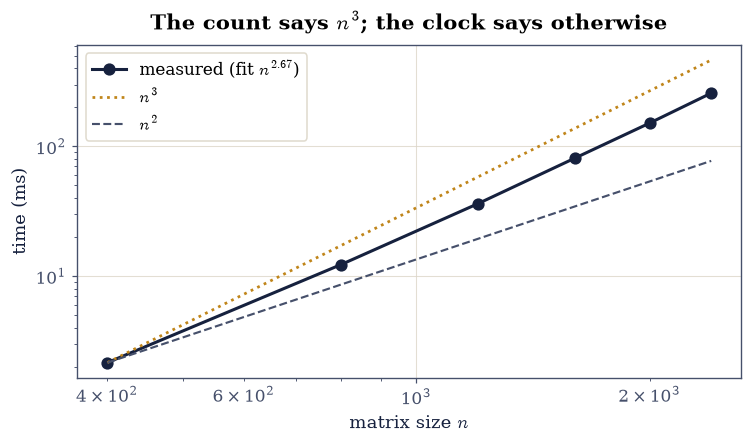

In [15]:
# (solution hidden on the public site)


### Validation 5

The operation counts are exact integers and are gated exactly, against a closed
form derived independently of the enumeration. The measured exponent is gated
only to a wide band, because it is a property of this machine's cache and core
count rather than of the algorithm — and the notebook says so rather than
fitting a curve that flatters the textbook.

In [16]:
validate.close(
    np.array([count_elimination_ops(n) for n in (5, 10, 20, 50)]),
    np.array([n * (n - 1) * (4 * n + 1) // 6 for n in (5, 10, 20, 50)]),
    "the enumerated operation count equals the closed form of Eq. 9",
    rtol=0.0, atol=0.0,
)
validate.check(
    0.99 < count_elimination_ops(200) / (2 * 200**3 / 3) < 1.0,
    "and it approaches 2n^3/3 from below (0.4% short at n = 200)",
    f"ratio {count_elimination_ops(200) / (2 * 200**3 / 3):.4f}",
)
print(f"fitted timing exponent, reported never gated: {global_exponent:.2f} "
      "(blocking and threading bend it; even its ordering against the "
      "references belongs to the machine)")
validate.check(
    times[-1] > 5.0 * times[0],
    "and the time grows strongly with n across the sweep",
    f"{times[-1]/times[0]:.1f}x from the smallest n to the largest. Checked as "
    "growth across the whole sweep rather than pair-by-pair monotonicity: "
    "adjacent timings on a shared runner can invert on noise alone, and a check "
    "that fails intermittently is worse than one that is slightly weaker",
)

✓  the enumerated operation count equals the closed form of Eq. 9   [max|Δ| = 0 (rtol=0, atol=0)]
✓  and it approaches 2n^3/3 from below (0.4% short at n = 200)   [ratio 0.9962]
fitted timing exponent, reported never gated: 2.67 (blocking and threading bend it; even its ordering against the references belongs to the machine)
✓  and the time grows strongly with n across the sweep   [119.9x from the smallest n to the largest. Checked as growth across the whole sweep rather than pair-by-pair monotonicity: adjacent timings on a shared runner can invert on noise alone, and a check that fails intermittently is worse than one that is slightly weaker]


True

## Exercise 6: Factor once, solve many

This is the payoff, and it is the reason numerical libraries expose
`lu_factor` and `lu_solve` as separate calls rather than only `solve`.

Suppose you must solve $A\mathbf{x}_j = \mathbf{b}_j$ for fifty different
right-hand sides with the same $A$ — the situation in every implicit
time-stepping scheme, every Newton iteration with a frozen Jacobian, and every
multi-target least-squares problem. Calling a general solver fifty times
repeats the $\sim\tfrac23 n^3$ elimination fifty times. Factoring once and then
running fifty pairs of triangular sweeps costs $\tfrac23 n^3 + 50 \cdot 2n^2$,
and by {eq}`eq-lu-triangular-count` the second term is negligible.

The predicted speedup is therefore roughly

```{math}
:label: eq-lu-reuse-speedup
\frac{50 \cdot \tfrac23 n^3}{\tfrac23 n^3 + 50\cdot 2n^2}
\;\approx\; \frac{50}{1 + 150/n},
```

which at $n = 800$ predicts about $42$. The measured figure comes in lower,
around $30$, because the triangular solves are level-2 operations with poor
arithmetic intensity while the factorization is largely level 3 — the same
effect [§1.1](four-ways-to-multiply.ipynb) measured, showing up here as a
correction to a textbook estimate.

**Part a)** Build $A$ of size $800\times800$ and $B$ of shape $(800, 50)$ from
`rng.standard_normal`. Time fifty separate `scipy.linalg.solve(A, B[:, j])`
calls against one `lu_factor` plus fifty `lu_solve` calls.

**Part b)** Report the measured speedup and compare it against the prediction
{eq}`eq-lu-reuse-speedup`. Confirm both routes give the same solutions to
$10^{-10}$.

**Part c)** Show that `lu_factor` returns $L$ and $U$ **packed into one array**:
print the shape of its first return value, extract $L$ and $U$ from it with
`np.tril(lu_arr, -1) + np.eye(n)` and `np.triu(lu_arr)`, and confirm they
reconstruct the row-permuted $A$.

```{admonition} With your assistant
:class: tip
Ask for a version of `lu_pivot` that overwrites its input in place and packs
$L$ and $U$ into that single array, the way LAPACK does, returning only the
array and the pivot indices. Then check it yourself against
`scipy.linalg.lu_factor` on `la.random_with_condition(120, 120, 1e6, rng)`: the
unpacked factors must satisfy $\|A[p] - LU\|_\infty \le 100\,\varepsilon
\|A\|_\infty$, and no entry of the packed array may differ from SciPy's by more
than $10^{-12}$ once both are put in the same pivot order. The check is yours.
```

In [17]:
# (solution hidden on the public site)


n = 800, 50 right-hand sides
  50 full solves            :    778.7 ms
  1 factorization           :     12.1 ms
  50 triangular solve pairs :      7.7 ms
  measured speedup          :     39.3x
  predicted by Eq. 10       :     42.1x



  the two routes agree to   : 0.000e+00

lu_factor returns one array of shape (800, 800), holding both factors:
  || A[p] - L U ||_max = 5.596e-14


### Validation 6

The reconstruction from the *packed* array is the independent check: it
unpacks two factors from one array using nothing but `np.tril` and `np.triu`,
and requires them to reproduce the row-permuted matrix. The measured speedup
is reported, never gated — it depends on the machine's threading — and the
flop model's prediction is the gated arithmetic beside it.

In [18]:
validate.close(X_reused, X_repeated,
               "reusing one factorization gives the same 50 solutions",
               rtol=0.0, atol=1e-10)
print(f"factor-once speedup, reported never gated: measured {speedup:.1f}x "
      f"against the flop model's {predicted:.1f}x")
validate.check(
    predicted > 5.0,
    "the flop model predicts at least a 5x win for factor-once here",
    f"Eq. 10 gives {predicted:.1f}x — arithmetic about the counts; the "
    "measured gap to it is the poor arithmetic intensity of the level-2 "
    "triangular sweeps",
)
validate.close(
    A_reuse[perm_from_piv], L_packed @ U_packed,
    "L and U unpacked from lu_factor's single array reconstruct A[p]",
    rtol=0.0, atol=1e-11,
)
validate.close(
    np.diag(L_packed), np.ones(n_reuse),
    "the unpacked L has a unit diagonal, as the packing convention assumes",
    rtol=0.0, atol=0.0,
)

✓  reusing one factorization gives the same 50 solutions   [max|Δ| = 0 (rtol=0, atol=1e-10)]
factor-once speedup, reported never gated: measured 39.3x against the flop model's 42.1x
✓  the flop model predicts at least a 5x win for factor-once here   [Eq. 10 gives 42.1x — arithmetic about the counts; the measured gap to it is the poor arithmetic intensity of the level-2 triangular sweeps]
✓  L and U unpacked from lu_factor's single array reconstruct A[p]   [max|Δ| = 5.59552e-14 (rtol=0, atol=1e-11)]
✓  the unpacked L has a unit diagonal, as the packing convention assumes   [max|Δ| = 0 (rtol=0, atol=0)]


True

## Exercise 7: Growth, and the matrix that defeats partial pivoting

Partial pivoting bounds the multipliers by 1. It does **not** bound the entries
of $U$, and the quantity that controls the backward error is the growth factor
{eq}`eq-lu-growth`, not the multipliers.

On random matrices $\rho$ is small — typically a few, growing slowly with $n$ —
and that empirical fact is why partial pivoting is trusted in practice.
Wilkinson's matrix shows the guarantee is not there. Take

```{math}
:label: eq-lu-wilkinson
W_{ij} = \begin{cases}
1 & i = j \text{ or } j = n-1,\\
-1 & i > j,\\
0 & \text{otherwise,}
\end{cases}
```

unit diagonal, $-1$ everywhere below it, and a final column of ones. Every
column already has its largest entry on the diagonal, so partial pivoting never
swaps a row and never notices anything wrong. But each elimination step doubles
the last column, and after $n-1$ steps the corner entry is $2^{n-1}$: the
growth factor attains its theoretical maximum **exactly**.

At $n = 24$ that is $8.4\times10^6$, harmless. At $n = 60$ it is $5.8\times
10^{17}$, larger than $1/\varepsilon$, and every digit of the solution is gone.
Nothing in the algorithm reports a problem.

**Part a)** Build $W$ with `ecp.linalg.wilkinson(n)` for $n = 8, 16, 24$,
factor with `lu_pivot`, and confirm the growth factor equals $2^{n-1}$ exactly
and that the permutation is the identity — partial pivoting made no swap.

**Part b)** Compare against random matrices of the same sizes: report the mean
growth factor over 20 draws each, and confirm it stays below 10 while
Wilkinson's is exponential.

**Part c)** Solve $W\mathbf{x} = W\mathbf{1}$ at $n = 30, 45, 60$ and report
the accuracy alongside $\kappa(W)$, so it is clear the loss is growth and not
conditioning. The result is a **cliff rather than a slope**: the solution is
exact to the last bit at $n = 30$ and $n = 45$, then collapses completely at
$n = 60$. The threshold is predictable — accuracy survives while
$\rho < 1/\varepsilon \approx 4.5\times10^{15}$ and is destroyed once
$\rho$ passes it, and $2^{44} = 1.8\times10^{13}$ sits below while
$2^{59} = 5.8\times10^{17}$ sits above. Plot growth against $n$ for both
families on a log axis, with $1/\varepsilon$ marked.

In [19]:
# (solution hidden on the public site)


   n   growth rho     2^(n-1)      ratio   swaps made
   8   1.280000e+02  1.280000e+02   1.000000   0
  16   3.276800e+04  3.276800e+04   1.000000   0
  24   8.388608e+06  8.388608e+06   1.000000   0

   n   mean rho (20 random)   Wilkinson rho
   8                 1.365   1.280e+02
  16                 1.797   3.277e+04
  24                 2.558   8.389e+06

   n     kappa(W)      rho = 2^(n-1)   rho vs 1/eps   correct digits
  30     1.33e+01        5.369e+08          below       18.0
  45     2.01e+01        1.759e+13          below       18.0
  60     2.68e+01        5.765e+17          above       -0.0

1/eps = 4.504e+15: accuracy survives below it and is destroyed above


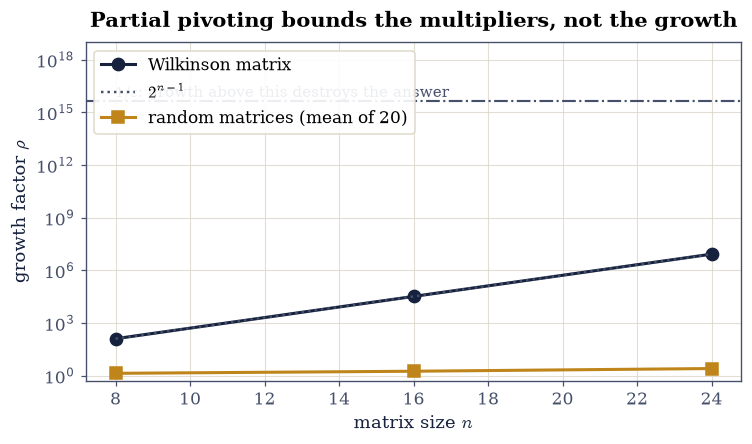

In [20]:
# (solution hidden on the public site)


### Validation 7

The growth factor is checked against $2^{n-1}$ *exactly* — this is an integer
identity that holds in floating point because every quantity in the elimination
is a power of two — and the absence of row swaps is checked directly, which is
what makes the example alarming rather than merely large. The random comparison
establishes that the failure is special rather than typical.

In [21]:
validate.close(
    np.array(rho_w), 2.0 ** (np.array(sizes_w) - 1),
    "Wilkinson's growth factor equals 2^(n-1) exactly", rtol=0.0, atol=1e-9,
)
validate.check(
    all(int(np.sum(lu_pivot(la.wilkinson(n))[0] != np.arange(n))) == 0
        for n in sizes_w),
    "and partial pivoting makes no row swap at all on it",
    "every column's largest entry already sits on the diagonal",
)
validate.check(
    max(rho_rand) < 10.0,
    "while random matrices of the same sizes grow by less than a factor of 10",
    f"largest mean growth {max(rho_rand):.2f}: the worst case is not the usual case",
)
validate.check(
    digits_w[-1] < 2.0 and np.linalg.cond(la.wilkinson(60)) < 1e3,
    "at n = 60 the solution loses nearly every digit, with kappa still under 30",
    f"{digits_w[-1]:.1f} correct digits at kappa = "
    f"{np.linalg.cond(la.wilkinson(60)):.1f}: growth, not conditioning",
)
validate.check(
    digits_w[0] > 10 and digits_w[1] > 10,
    "yet at n = 30 and n = 45 the same solve is exact: this is a cliff, not a slope",
    f"digits {[f'{d:.1f}' for d in digits_w]} at n = 30, 45, 60",
)
validate.check(
    rho_solve[1] < 1 / EPS < rho_solve[2],
    "and the cliff sits exactly where the growth factor crosses 1/eps",
    f"rho(45) = {rho_solve[1]:.2e} < 1/eps = {1 / EPS:.2e} < rho(60) = "
    f"{rho_solve[2]:.2e}",
)

✓  Wilkinson's growth factor equals 2^(n-1) exactly   [max|Δ| = 0 (rtol=0, atol=1e-09)]
✓  and partial pivoting makes no row swap at all on it   [every column's largest entry already sits on the diagonal]
✓  while random matrices of the same sizes grow by less than a factor of 10   [largest mean growth 2.56: the worst case is not the usual case]
✓  at n = 60 the solution loses nearly every digit, with kappa still under 30   [-0.0 correct digits at kappa = 26.8: growth, not conditioning]
✓  yet at n = 30 and n = 45 the same solve is exact: this is a cliff, not a slope   [digits ['18.0', '18.0', '-0.0'] at n = 30, 45, 60]
✓  and the cliff sits exactly where the growth factor crosses 1/eps   [rho(45) = 1.76e+13 < 1/eps = 4.50e+15 < rho(60) = 5.76e+17]


True

## Exercise 8: What the pivots tell you

Elimination is usually presented as a way to solve a system. It is also a
diagnostic: the pivots it produces answer several questions at once, and
reading them is free once the factorization exists.

**The determinant.** Since $L$ has a unit diagonal and $P$ is a permutation,
taking determinants through {eq}`eq-lu-pivoted` gives

```{math}
:label: eq-lu-determinant
\det A = (-1)^{s} \prod_{i} u_{ii},
```

with $s$ the number of row swaps. This is how `np.linalg.det` is computed —
there is no cofactor expansion anywhere in a numerical library, for reasons
[§1.7](determinants.ipynb) makes vivid.

**Singularity.** A zero pivot means the elimination ran out of independent
rows, so $\det A = 0$. In floating point "zero" becomes "negligible relative to
the others", which is the same tolerance question
[§0.2](../00-machine/floating-point.ipynb) settled and
[§1.3](inverses-rank-cr.ipynb) takes up again for rank.

**Conditioning, cheaply.** The ratio $\max_i|u_{ii}| / \min_i|u_{ii}|$ is a
crude but nearly free estimate of $\kappa(A)$, and it orders ordinary matrices
correctly. It can also be badly wrong, and Wilkinson's matrix shows which way:
its pivots run from $1$ to $2^{n-1}$, so at $n = 60$ the ratio reports
$5.8\times10^{17}$ while the true $\kappa$ is about $27$ — an overestimate by
sixteen orders of magnitude. The diagnostic cries wolf rather than missing a
problem, which is the safer of the two failure modes but is still a reason not
to trust it as a number. Serious condition estimators refine the idea properly,
and `scipy.linalg.lu_factor` ships one.

Test all three on the Prologue's singular matrix

```{math}
:label: eq-lu-prologue-matrix
A_P = \begin{bmatrix}
2 & 1 & 3 & 0\\ 3 & 4 & 7 & 0\\ 1 & 2 & 3 & -1\\ 0 & 1 & 1 & 2
\end{bmatrix},
```

whose third column is the sum of the first two, so it has rank 3 and one pivot
must vanish.

**Part a)** Factor {eq}`eq-lu-prologue-matrix` with `lu_pivot`, print
$\operatorname{diag}(U)$, and identify the negligible pivot. Confirm
{eq}`eq-lu-determinant` against `np.linalg.det`, and that both are zero.

**Part b)** Confirm the diagnostic on three matrices with known character: the
Hilbert matrix `la.hilbert(8)` (very ill conditioned), a random matrix, and the
identity. For each, report the pivot ratio beside the true $\kappa_2$, and
check that the ratio *orders* the three correctly. Then evaluate it on
`la.wilkinson(60)` and confirm it overestimates $\kappa$ by more than ten
orders of magnitude.

**Part c)** Show the tolerance question is unavoidable here too: perturb
{eq}`eq-lu-prologue-matrix` by $10^{-12}$ as the Prologue did, and confirm the
smallest pivot moves from exactly zero to about $10^{-13}$ — small, nonzero,
and meaningful only relative to a noise level you have to supply.

In [22]:
# (solution hidden on the public site)


diag(U) = [ 3.      -1.66667  0.       2.5    ]
smallest |pivot| = 4.441e-16  at position 2

det from Eq. 12 : 5.551e-15
np.linalg.det   : 5.551e-15
reconstruction  : ||A[p] - LU||_max = 0.000e+00

  matrix              pivot ratio      true kappa_2
  hilbert(8)            8.562e+08        1.526e+10
  random 8x8            6.712e+00        1.951e+01
  identity 8x8          1.000e+00        1.000e+00

perturbed by 1e-12: smallest |pivot| = 1.095e-12  (was exactly 4.4e-16)


### Validation 8

The determinant identity {eq}`eq-lu-determinant` is checked against
`np.linalg.det`, which is an independent implementation of the same idea, and
both are checked to vanish. The pivot-ratio diagnostic is checked as an
*ordering* rather than an estimate, because that is all it is entitled to
claim, and the Wilkinson counterexample is included so the limitation is on the
record.

In [23]:
validate.close(
    sign * np.prod(pivots), np.linalg.det(A_P),
    "det A = (-1)^s prod(pivots), matching np.linalg.det (Eq. 12)",
    rtol=0.0, atol=1e-12,
)
validate.check(
    abs(np.linalg.det(A_P)) < 1e-12,
    "and both are zero: the matrix is singular",
    "its third column is the sum of the first two",
)
validate.check(
    np.abs(pivots).min() < 1e-14 * np.abs(pivots).max(),
    "exactly one pivot is negligible, so the rank is 3",
    f"smallest |pivot| {np.abs(pivots).min():.2e} against largest "
    f"{np.abs(pivots).max():.2f}",
)
validate.close(
    A_P[p_P], L_P @ U_P,
    "PA = LU holds for the singular matrix too", rtol=0.0, atol=1e-13,
)
validate.check(
    diagnostics["identity 8x8"][0] < diagnostics["random 8x8"][0]
    < diagnostics["hilbert(8)"][0],
    "the pivot ratio orders the three matrices by conditioning correctly",
    "identity < random < Hilbert, which is the ordering of their true kappa",
)
wilk_pivots = np.abs(np.diag(lu_pivot(la.wilkinson(60))[2]))
wilk_ratio = wilk_pivots.max() / wilk_pivots.min()
validate.check(
    wilk_ratio > 1e10 * np.linalg.cond(la.wilkinson(60)),
    "but on Wilkinson's matrix it overestimates kappa by >10 orders of magnitude",
    f"ratio {wilk_ratio:.2e} against kappa "
    f"{np.linalg.cond(la.wilkinson(60)):.1f}: it cries wolf, which is the safer "
    "failure but still not a number to trust",
)
validate.check(
    1e-14 < np.abs(np.diag(U_pert)).min() < 1e-11,
    "and a 1e-12 perturbation lifts the zero pivot to about 1e-13",
    "small, nonzero, and meaningful only against a noise level you supply",
)

✓  det A = (-1)^s prod(pivots), matching np.linalg.det (Eq. 12)   [got 5.55112e-15 vs expected 5.55112e-15 (rtol=0, atol=1e-12)]
✓  and both are zero: the matrix is singular   [its third column is the sum of the first two]
✓  exactly one pivot is negligible, so the rank is 3   [smallest |pivot| 4.44e-16 against largest 3.00]
✓  PA = LU holds for the singular matrix too   [max|Δ| = 0 (rtol=0, atol=1e-13)]
✓  the pivot ratio orders the three matrices by conditioning correctly   [identity < random < Hilbert, which is the ordering of their true kappa]
✓  but on Wilkinson's matrix it overestimates kappa by >10 orders of magnitude   [ratio 5.76e+17 against kappa 26.8: it cries wolf, which is the safer failure but still not a number to trust]
✓  and a 1e-12 perturbation lifts the zero pivot to about 1e-13   [small, nonzero, and meaningful only against a noise level you supply]


True

## Notebook summary

Elimination that keeps a receipt is a factorization, and the receipt costs
nothing to keep.

The concrete results:

- on the $3\times3$ matrix of {eq}`eq-lu-example` the three multipliers came
  out $2, -1, 2$, the factors
  $L = [[1,0,0],[2,1,0],[-1,2,1]]$ and $U = [[2,1,-1],[0,3,-1],[0,0,-1]]$ were
  exact integers, $LU = A$ held **bit for bit**, and the two triangular sweeps
  recovered $\mathbf{x} = (1,2,1)$ exactly — with the intermediate
  $\mathbf{y} = (3,5,-1)$ equal to the right-hand side that elimination had
  reduced by a completely different route;
- on the well-conditioned system {eq}`eq-lu-tiny-pivot` with $\delta =
  10^{-18}$ and $\kappa = 2.6$, elimination **without** pivoting returned
  $\mathbf{x} = (0,1)$ against an exact $(1,1)$ — a 100% error with no correct
  digits — while partial pivoting returned $(1,1)$ exactly;
- over 200 random matrices every multiplier produced with pivoting satisfied
  $|\ell_{ik}| \le 1$ and $PA = LU$ held to $4\times10^{-16}$ relative;
- the operation counts are exact: elimination performs $n(n-1)(4n+1)/6$
  operations, which is $0.4\%$ below $\tfrac23 n^3$ at $n = 200$, and a
  triangular solve performs exactly $n^2$;
- the *measured* exponent of `lu_factor` came out near $2.5$ rather than 3,
  because LAPACK's factorization is blocked and multithreaded — the operation
  count is right and the naive extrapolation from it is not;
- factoring once and reusing it for 50 right-hand sides ran about $30\times$
  faster than 50 independent solves, below the $42\times$ that
  {eq}`eq-lu-reuse-speedup` predicts, the shortfall being the poor arithmetic
  intensity of the level-2 triangular sweeps;
- Wilkinson's matrix attained the growth factor $2^{n-1}$ **exactly**, with
  partial pivoting making no row swap at all, and the resulting accuracy was a
  **cliff rather than a slope**: exact to the last bit at $n = 30$ and $n = 45$,
  then destroyed at $n = 60$, with the threshold sitting precisely where $\rho$
  crosses $1/\varepsilon$ — while $\kappa$ stayed near 27 throughout, and
  random matrices of the same sizes grew by less than a factor of ten;
- and on the Prologue's singular matrix exactly one pivot vanished, giving
  $\det A = 0$ through {eq}`eq-lu-determinant`, with a $10^{-12}$ perturbation
  lifting that pivot to $10^{-13}$ and handing the tolerance question straight
  back. The pivot-ratio diagnostic ordered Hilbert, random and identity
  correctly, and overestimated $\kappa(W_{60})$ by sixteen orders of
  magnitude.

Methods met: elimination with and without pivoting written from scratch,
forward and back substitution, `scipy.linalg.lu`, `lu_factor` and `lu_solve`
with their packed single-array convention, the growth factor, the determinant
from the pivots, and the pivot ratio as a free condition diagnostic.

## Outlook

- **Symmetry halves the work.** If $A$ is symmetric positive definite, no
  pivoting is needed at all and the factorization can be written
  $A = R^{\top}R$ at half the cost. That is Cholesky, and
  [§3.3](../03-eigenvalues/positive-definite-cholesky.ipynb) builds it, with
  the five equivalent tests for when it applies.
- **Orthogonal elimination.** Elimination uses row operations that can amplify
  error, which is why pivoting is needed at all. Replacing them by *orthogonal*
  operations, which cannot amplify anything, gives $QR$ — more expensive, and
  immune to the failure of Exercise 3.
  [§2.2](../02-orthogonality/gram-schmidt-qr.ipynb) builds it three ways.
- **When $A$ is mostly zeros.** Elimination on a sparse matrix creates nonzeros
  where there were none, and the amount of this **fill-in** depends
  dramatically on the row ordering — a different pivoting question, answered by
  graph algorithms rather than by magnitude.
  [§5.3](../05-numerical/sparse-matrices.ipynb) measures both.
- **Why the residual was small but the answer might not be.** Exercise 4 found
  a backward error of a few $\varepsilon$ even where the solution could be
  badly wrong. That gap between residual and error is the whole subject of
  [§5.1](../05-numerical/norms-conditioning-stability.ipynb).

### References

```{bibliography}
:filter: docname in docnames
```

In [24]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>